In [1]:

import tensorflow as tf             # Main deep learning library
import numpy as np                  # For numerical operations (arrays, matrices)
import matplotlib.pyplot as plt      # For plotting graphs and images

# Dataset
from tensorflow.keras.datasets import cifar10  # CIFAR-10 image dataset

# Model and Layers
from tensorflow.keras import layers, models    # To build neural network models

# Pretrained model
from tensorflow.keras.applications import MobileNetV2  # Pretrained CNN model

# Utilities
from sklearn.metrics import classification_report, confusion_matrix # Evaluation metrics
import seaborn as sns               # For better visualization (like heatmaps)

In [2]:
# Load CIFAR-10 dataset (automatically split into train and test)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# x_train → training images
# y_train → labels for training images
# x_test → testing images
# y_test → labels for testing images

# Print shapes to understand the data structure
print("Train shape:", x_train.shape)
# Example: (50000, 32, 32, 3) -> 50k images, each 32x32 with 3 color channels

print("Test shape:", x_test.shape)
# Example: (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),  # Randomly flips images left & right
  layers.RandomRotation(0.1),       # Slightly rotates images (10% range)
  layers.RandomZoom(0.1)            # Slightly zooms in/out
])

In [5]:
base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
base_model.trainable = False

/tmp/ipykernel_4076/3855651900.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32, 32, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model = models.Sequential([
    data_augmentation,   #random transform
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Compile the model (configure how it learns)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Optimizer to update weights
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Metric to track performance
)

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
#train model
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 53ms/step - accuracy: 0.2353 - loss: 2.0704 - val_accuracy: 0.2699 - val_loss: 1.9995
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 48ms/step - accuracy: 0.2639 - loss: 2.0011 - val_accuracy: 0.2886 - val_loss: 1.9485
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.2648 - loss: 1.9914 - val_accuracy: 0.2947 - val_loss: 1.9337
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.2685 - loss: 1.9857 - val_accuracy: 0.2933 - val_loss: 1.9284
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.2748 - loss: 1.9771 - val_accuracy: 0.3018 - val_loss: 1.9205
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.2755 - loss: 1.9699 - val_accuracy: 0.3094 - val_loss: 1.9143
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.2768 - loss: 1.9698 - val_accuracy: 0.3093 - val_loss: 1.9099
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.2779 

In [11]:
# Unfreeze top layers of base model
base_model.trainable = True

# Freeze initial layers, train only deeper layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 208s 123ms/step - accuracy: 0.1487 - loss: 9.5642 - val_accuracy: 0.1561 - val_loss: 2.9282
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 120ms/step - accuracy: 0.1733 - loss: 3.0914 - val_accuracy: 0.1936 - val_loss: 2.2474
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 205s 123ms/step - accuracy: 0.1814 - loss: 2.3915 - val_accuracy: 0.2314 - val_loss: 2.0885
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 188s 120ms/step - accuracy: 0.2026 - loss: 2.2195 - val_accuracy: 0.2630 - val_loss: 1.9945
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 189s 121ms/step - accuracy: 0.2224 - loss: 2.1268 - val_accuracy: 0.3016 - val_loss: 1.9109


313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step
              precision    recall  f1-score   support

           0       0.34      0.41      0.37      1000
           1       0.35      0.38      0.37      1000
           2       0.25      0.10      0.14      1000
           3       0.24      0.12      0.16      1000
           4       0.26      0.22      0.24      1000
           5       0.31      0.20      0.25      1000
           6       0.32      0.46      0.38      1000
           7       0.28      0.24      0.26      1000
           8       0.27      0.39      0.32      1000
           9       0.31      0.50      0.38      1000

    accuracy                           0.30     10000
   macro avg       0.29      0.30      0.29     10000
weighted avg       0.29      0.30      0.29     10000



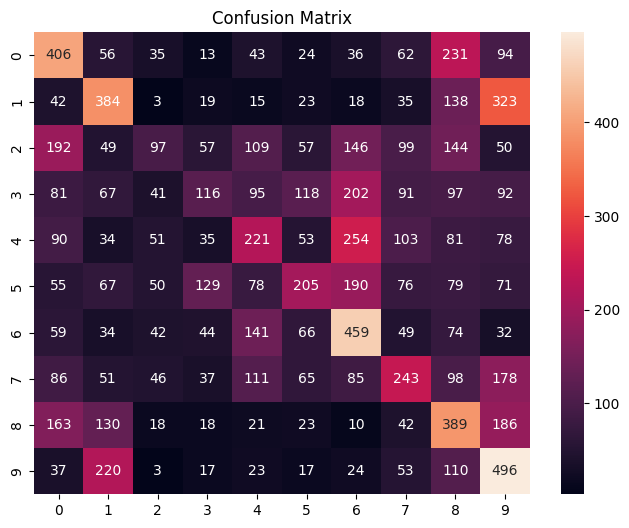

In [12]:
# Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

yolo **object** detection

In [13]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.9 MB/s eta 0:00:00


In [14]:
from ultralytics import YOLO
yolo_model = YOLO('yolov8n.pt')

In [15]:
results = yolo_model('https://ultralytics.com/images/bus.jpg', save=True)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 457.4ms
Speed: 16.9ms preprocess, 457.4ms inference, 55.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


In [25]:
for r in results:
  print("objects detected:", len(r.boxes))

objects detected: 15


In [27]:
# Upload Custom Image
from google.colab import files
uploaded = files.upload()

for img in uploaded.keys():
    results = yolo_model(img, save=True)

Saving sssss.webp to sssss (2).webp

image 1/1 /content/sssss (2).webp: 384x640 9 persons, 5 cars, 1 traffic light, 134.1ms
Speed: 2.4ms preprocess, 134.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
